In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib

import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

c:\Users\user\OneDrive\Desktop\speechbanana\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:

# CONFIG

BASE_DIR = "C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (299, 299)

OUT_DIR = "hybrid_model"
os.makedirs(OUT_DIR, exist_ok=True)

RF_PATH = os.path.join(OUT_DIR, "hybrid_rf.joblib")
LE_PATH = os.path.join(OUT_DIR, "label_encoder.joblib")
META_PATH = os.path.join(OUT_DIR, "meta.json")

print("TF version:", tf.__version__)
print("TRAIN:", TRAIN_DIR)
print("TEST :", TEST_DIR)

TF version: 2.20.0
TRAIN: C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\train
TEST : C://Users//user//OneDrive//Desktop//speechbanana//dataset_split.1\test


In [ ]:

#  CNN FEATURE EXTRACTOR

base = InceptionV3(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False
x = GlobalAveragePooling2D()(base.output)
cnn_model = Model(inputs=base.input, outputs=x)

def extract_cnn_features(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    feat = cnn_model.predict(arr, verbose=0)[0]
    return feat.astype(np.float32)

In [4]:

# HYBRID FEATURE BUILDER

def extract_hybrid_vector(image_path):
    # CNN embedding
    cnn_feat = extract_cnn_features(image_path)

    # Threshold features (YOU ALREADY HAVE THESE FUNCTIONS)
    thr = extract_thresholds_from_image(image_path, debug=False)
    thr_feats = thresholds_to_features(thr)

    thr_vec = np.array(list(thr_feats.values()), dtype=np.float32)

    # concat
    hybrid = np.concatenate([cnn_feat, thr_vec])
    return hybrid, thr_feats

In [5]:

# LOAD DATASET FROM FOLDERS

def list_images(root_dir):
    rows = []
    labels = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    labels.sort()

    for label in labels:
        folder = os.path.join(root_dir, label)
        for fn in os.listdir(folder):
            if fn.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({"label": label, "image_path": os.path.join(folder, fn)})
    return pd.DataFrame(rows)

train_df = list_images(TRAIN_DIR)
test_df  = list_images(TEST_DIR)

print("Train images:", len(train_df))
print("Test images :", len(test_df))

Train images: 634
Test images : 199


In [2]:
import os
import json
import cv2
import joblib
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model

# =========================
# 0) CONFIG
# =========================
BASE_DIR  = r"C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

OUT_DIR = "hybrid_model_artifacts_v2"
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_PATH_SVM = os.path.join(OUT_DIR, "hybrid_svm.joblib")
MODEL_PATH_RF  = os.path.join(OUT_DIR, "hybrid_rf.joblib")
LE_PATH        = os.path.join(OUT_DIR, "label_encoder.joblib")
META_PATH      = os.path.join(OUT_DIR, "meta.json")

FREQS = [500, 1000, 2000, 3000, 4000, 6000, 8000]
NUM_POINTS = len(FREQS)

DB_MIN = -10
DB_MAX = 110

IMG_SIZE = (299, 299)
IMG_EXTS = (".png", ".jpg", ".jpeg")

# Reduce CNN features to avoid dominating thresholds
PCA_DIM = 64   # try 32, 64, 128

# =========================
# 1) THRESHOLD EXTRACTION
# =========================
def extract_thresholds_from_image(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise RuntimeError(f"Could not read image: {image_path}")

    h, w = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([60, 15, 15])
    upper_blue = np.array([170, 255, 255])
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    num_labels, _, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    pts = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if 3 <= area <= 3000:
            cx, cy = centroids[i]
            pts.append((float(cx), float(cy), int(area)))

    if len(pts) < 2:
        # fallback: flat curve if detection fails
        fallback = (DB_MIN + DB_MAX) / 2.0
        return np.array([fallback] * NUM_POINTS, dtype=np.float32)

    pts.sort(key=lambda x: x[0])

    xs = np.array([p[0] for p in pts], dtype=np.float32)
    x_min, x_max = np.percentile(xs, 5), np.percentile(xs, 95)
    expected_x = np.linspace(x_min, x_max, NUM_POINTS).astype(np.float32)

    col_points = {i: [] for i in range(NUM_POINTS)}
    for (cx, cy, area) in pts:
        j = int(np.argmin(np.abs(expected_x - cx)))
        col_points[j].append((cx, cy, area))

    chosen = [None] * NUM_POINTS
    for j in range(NUM_POINTS):
        if col_points[j]:
            chosen[j] = max(col_points[j], key=lambda t: t[2])

    def y_to_db(y):
        return DB_MIN + (y / (h - 1)) * (DB_MAX - DB_MIN)

    thresholds = [None] * NUM_POINTS
    for j in range(NUM_POINTS):
        if chosen[j] is not None:
            thresholds[j] = float(y_to_db(chosen[j][1]))

    idxs = np.arange(NUM_POINTS)
    known = np.array([t is not None for t in thresholds], dtype=bool)

    if known.sum() == 0:
        fallback = (DB_MIN + DB_MAX) / 2.0
        thresholds = [fallback] * NUM_POINTS
    else:
        known_x = idxs[known]
        known_y = np.array([thresholds[i] for i in known_x], dtype=np.float32)
        for j in range(NUM_POINTS):
            if thresholds[j] is None:
                thresholds[j] = float(np.interp(j, known_x, known_y))

    thresholds = [float(np.clip(t, DB_MIN, DB_MAX)) for t in thresholds]
    return np.array(thresholds, dtype=np.float32)

def thresholds_to_features(thr):
    thr = np.array(thr, dtype=np.float32)
    speech_avg = float(np.mean(thr[0:5]))
    high_avg   = float(np.mean(thr[4:7]))
    low_avg    = float(np.mean(thr[0:3]))
    slope      = float(high_avg - low_avg)
    return np.array([
        thr[0], thr[1], thr[2], thr[3], thr[4], thr[5], thr[6],
        np.mean(thr), np.max(thr), np.min(thr),
        speech_avg, low_avg, high_avg, slope, np.var(thr)
    ], dtype=np.float32)

# =========================
# 2) CNN FEATURE EXTRACTOR
# =========================
base = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
# Optional: freeze to avoid accidental training (we only do inference)
base.trainable = False

cnn_model = Model(inputs=base.input, outputs=base.output)

def extract_cnn_features(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    x = tf.keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    feat = cnn_model.predict(x, verbose=0)[0]  # 2048-d
    return feat.astype(np.float32)

# =========================
# 3) HYBRID VECTOR
# =========================
def extract_hybrid_vector(image_path):
    thr = extract_thresholds_from_image(image_path)
    thr_vec = thresholds_to_features(thr)      # 15 dims
    cnn_vec = extract_cnn_features(image_path) # 2048 dims
    return thr_vec, cnn_vec, thr

# =========================
# 4) BUILD DATASET FROM FOLDERS
# =========================
def build_dataset(root_dir, max_errors=5):
    X_thr, X_cnn, y = [], [], []
    shown = 0
    total = 0

    labels = sorted([d for d in os.listdir(root_dir)
                     if os.path.isdir(os.path.join(root_dir, d))])

    for label in labels:
        cls_dir = os.path.join(root_dir, label)
        imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(IMG_EXTS)]
        for fn in imgs:
            total += 1
            path = os.path.join(cls_dir, fn)
            try:
                thr_vec, cnn_vec, _ = extract_hybrid_vector(path)
                X_thr.append(thr_vec)
                X_cnn.append(cnn_vec)
                y.append(label)
            except Exception as e:
                if shown < max_errors:
                    print("[WARN]", path, "->", e)
                    shown += 1

    return np.array(X_thr), np.array(X_cnn), np.array(y), total

print("\nBuilding TRAIN...")
Xthr_train, Xcnn_train, y_train, total_train = build_dataset(TRAIN_DIR)
print("Train total:", total_train, "used:", len(y_train))

print("\nBuilding TEST...")
Xthr_test, Xcnn_test, y_test, total_test = build_dataset(TEST_DIR)
print("Test total:", total_test, "used:", len(y_test))

# =========================
# 5) LABEL ENCODING
# =========================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
joblib.dump(le, LE_PATH)

# =========================
# 6) PCA FOR CNN + STANDARDIZE
# =========================
scaler_thr = StandardScaler()
scaler_cnn = StandardScaler()
pca = PCA(n_components=PCA_DIM, random_state=42)

# Fit on TRAIN only
Xthr_train_s = scaler_thr.fit_transform(Xthr_train)
Xcnn_train_s = scaler_cnn.fit_transform(Xcnn_train)
Xcnn_train_p = pca.fit_transform(Xcnn_train_s)

# Transform TEST
Xthr_test_s = scaler_thr.transform(Xthr_test)
Xcnn_test_s = scaler_cnn.transform(Xcnn_test)
Xcnn_test_p = pca.transform(Xcnn_test_s)

# Final HYBRID vector
X_train = np.concatenate([Xthr_train_s, Xcnn_train_p], axis=1)
X_test  = np.concatenate([Xthr_test_s,  Xcnn_test_p], axis=1)

print("\nHybrid dim:", X_train.shape[1], f"(thr=15 + pca_cnn={PCA_DIM})")

# =========================
# 7) TRAIN MODELS
# =========================
svm = SVC(
    C=5,
    gamma="scale",
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)
svm.fit(X_train, y_train_enc)

rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    class_weight="balanced",
    max_depth=None,
    n_jobs=-1  # faster
)
rf.fit(X_train, y_train_enc)

# =========================
# 8) EVALUATE (BOTH MODELS)
# =========================
def evaluate(model, name):
    print("\n" + "="*70)
    print(f" EVALUATION: {name}")
    print("="*70)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_enc, y_pred)

    print(f"✅ {name} Accuracy: {acc*100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_enc, y_pred))

evaluate(svm, "Hybrid SVM")
evaluate(rf,  "Hybrid Random Forest")

# =========================
# 8.1) SAVE ARTIFACTS
# =========================
joblib.dump(
    {"model": svm, "scaler_thr": scaler_thr, "scaler_cnn": scaler_cnn, "pca": pca},
    MODEL_PATH_SVM
)
joblib.dump(
    {"model": rf,  "scaler_thr": scaler_thr, "scaler_cnn": scaler_cnn, "pca": pca},
    MODEL_PATH_RF
)

meta = {
    "labels": list(le.classes_),
    "pca_dim": PCA_DIM,
    "hybrid_dim": int(X_train.shape[1]),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
}
with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("\n✅ Saved models + scalers + PCA into:", OUT_DIR)

# =========================
# 9) PREDICT FROM ANY IMAGE PATH (ONE FUNCTION)
# =========================
def _load_bundle(model_type="svm"):
    le_loaded = joblib.load(LE_PATH)
    if model_type.lower() == "rf":
        bundle = joblib.load(MODEL_PATH_RF)
    else:
        bundle = joblib.load(MODEL_PATH_SVM)
    return le_loaded, bundle

def predict_hybrid(image_path, model_type="svm", top_k=5):
    le_loaded, bundle = _load_bundle(model_type=model_type)

    model = bundle["model"]
    scaler_thr = bundle["scaler_thr"]
    scaler_cnn = bundle["scaler_cnn"]
    pca = bundle["pca"]

    thr_vec, cnn_vec, thr_raw = extract_hybrid_vector(image_path)

    thr_s = scaler_thr.transform(thr_vec.reshape(1, -1))
    cnn_s = scaler_cnn.transform(cnn_vec.reshape(1, -1))
    cnn_p = pca.transform(cnn_s)

    X = np.concatenate([thr_s, cnn_p], axis=1)

    probs = model.predict_proba(X)[0]
    order = np.argsort(probs)[::-1]

    pred_idx = int(order[0])
    pred_label = le_loaded.inverse_transform([pred_idx])[0]
    conf = float(probs[pred_idx])

    top = [(le_loaded.inverse_transform([i])[0], float(probs[i])) for i in order[:top_k]]

    return {
        "image_path": image_path,
        "model_type": model_type.lower(),
        "predicted_label": pred_label,
        "confidence_percent": round(conf * 100, 2),
        "top_k": [(lbl, round(p * 100, 2)) for (lbl, p) in top],
        "thresholds_db": [round(v, 1) for v in thr_raw.tolist()],
        "freqs": FREQS
    }

# Example usage:
# img_path = r"C:\Users\user\OneDrive\Desktop\speechbanana\dataset_split.1\test\Mild\audiogram_100.png"
# print(predict_hybrid(img_path, model_type="svm"))
# print(predict_hybrid(img_path, model_type="rf"))



Building TRAIN...
Train total: 634 used: 634

Building TEST...
Test total: 199 used: 199

Hybrid dim: 79 (thr=15 + pca_cnn=64)

 EVALUATION: Hybrid SVM
✅ Hybrid SVM Accuracy: 88.44%

Classification Report:
                   precision    recall  f1-score   support

             Mild       0.95      0.88      0.91        40
         Moderate       0.82      0.95      0.88        39
Moderately severe       0.82      0.79      0.81        34
           Normal       0.95      0.95      0.95        40
         Profound       0.85      1.00      0.92        17
           Severe       0.92      0.76      0.83        29

         accuracy                           0.88       199
        macro avg       0.88      0.89      0.88       199
     weighted avg       0.89      0.88      0.88       199

Confusion Matrix:
[[35  3  0  2  0  0]
 [ 0 37  2  0  0  0]
 [ 0  5 27  0  0  2]
 [ 2  0  0 38  0  0]
 [ 0  0  0  0 17  0]
 [ 0  0  4  0  3 22]]

 EVALUATION: Hybrid Random Forest
✅ Hybrid Random Fore

In [7]:

# ENCODE LABELS

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


Classification Report:

                   precision    recall  f1-score   support

             Mild     0.9189    0.8500    0.8831        40
         Moderate     0.8636    0.9744    0.9157        39
Moderately severe     0.9091    0.8824    0.8955        34
           Normal     0.9487    0.9250    0.9367        40
         Profound     0.8421    0.9412    0.8889        17
           Severe     0.8889    0.8276    0.8571        29

         accuracy                         0.8995       199
        macro avg     0.8952    0.9001    0.8962       199
     weighted avg     0.9015    0.8995    0.8991       199


Confusion Matrix (counts):

                   Mild  Moderate  Moderately severe  Normal  Profound  Severe
Mild                 34         4                  0       2         0       0
Moderate              0        38                  1       0         0       0
Moderately severe     0         2                 30       0         0       2
Normal                3         0    

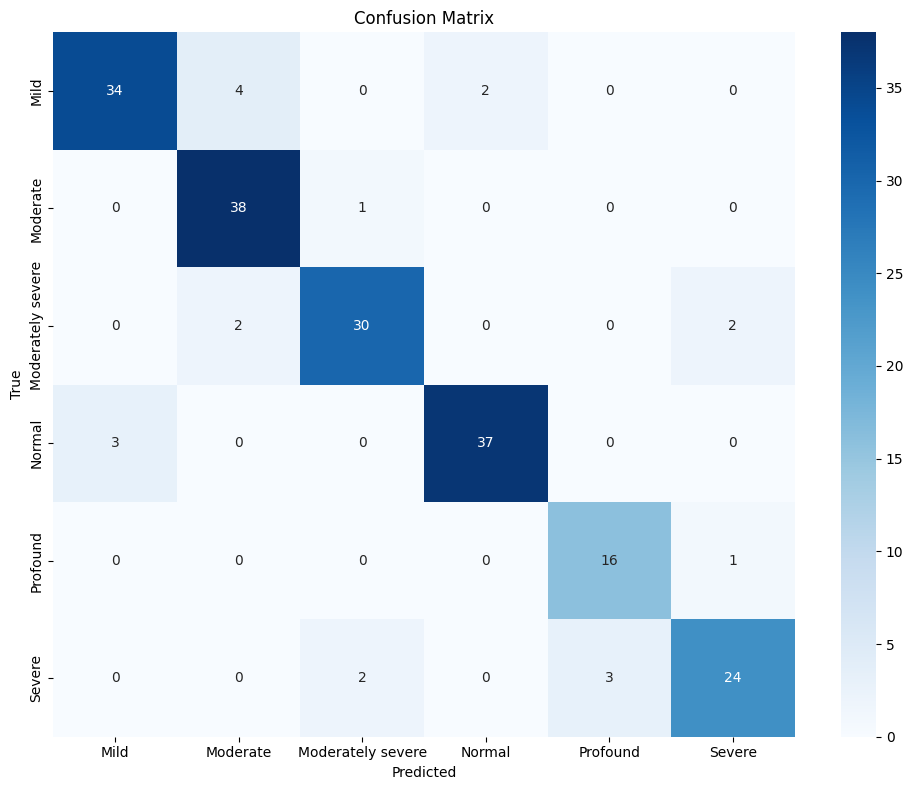

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) Classification Report
# -------------------------
report_text = classification_report(
    y_test_enc, y_pred,
    target_names=le.classes_,
    digits=4
)
print("\nClassification Report:\n")
print(report_text)

# Optional: save report to txt
with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write(report_text)

# -------------------------
# 2) Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test_enc, y_pred)

# Make it readable as a table
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nConfusion Matrix (counts):\n")
print(cm_df)

# Optional: save confusion matrix as CSV
cm_df.to_csv(os.path.join(OUT_DIR, "confusion_matrix.csv"))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Optional: save plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=200)
plt.close()


In [31]:
import numpy as np
import joblib

def predict_hybrid_detailed(image_path, model_type="svm", top_k=5):
    # load artifacts
    le = joblib.load(LE_PATH)

    if model_type.lower() == "rf":
        bundle = joblib.load(MODEL_PATH_RF)
    else:
        bundle = joblib.load(MODEL_PATH_SVM)

    model = bundle["model"]
    scaler_thr = bundle["scaler_thr"]
    scaler_cnn = bundle["scaler_cnn"]
    pca = bundle["pca"]

    # ✅ extract components (3 outputs!)
    thr_vec, cnn_vec, thr_raw = extract_hybrid_vector(image_path)

    # preprocess like training
    thr_s = scaler_thr.transform(thr_vec.reshape(1, -1))
    cnn_s = scaler_cnn.transform(cnn_vec.reshape(1, -1))
    cnn_p = pca.transform(cnn_s)

    # final hybrid vector
    X = np.concatenate([thr_s, cnn_p], axis=1)

    # predict
    probs = model.predict_proba(X)[0]
    order = np.argsort(probs)[::-1]

    pred_idx = int(order[0])
    pred_label = le.inverse_transform([pred_idx])[0]
    conf = float(probs[pred_idx])

    top = [(le.classes_[i], float(probs[i])) for i in order[:top_k]]

    return {
        "image_path": image_path,
        "model_type": model_type,
        "predicted_label": pred_label,
        "confidence": conf,
        "top_k": top,
        "thresholds_db": [round(x, 1) for x in thr_raw.tolist()],
        "freqs": FREQS,
        "all_class_probs": {le.classes_[i]: float(probs[i]) for i in range(len(probs))}
    }


In [32]:
img_path = "C://Users//user//OneDrive//Desktop//speechbanana//test4.png"
result = predict_hybrid_detailed(img_path, top_k=5)
print(result)


{'image_path': 'C://Users//user//OneDrive//Desktop//speechbanana//test4.png', 'model_type': 'svm', 'predicted_label': np.str_('Severe'), 'confidence': 0.9939619940012779, 'top_k': [(np.str_('Severe'), 0.9939619940012779), (np.str_('Moderately severe'), 0.003200176547834855), (np.str_('Mild'), 0.0009765161742574899), (np.str_('Normal'), 0.0006885026733623566), (np.str_('Moderate'), 0.0006517559062635093)], 'thresholds_db': [67.5, 76.2, 72.0, 66.4, 68.4, 71.2, 80.2], 'freqs': [500, 1000, 2000, 3000, 4000, 6000, 8000], 'all_class_probs': {np.str_('Mild'): 0.0009765161742574899, np.str_('Moderate'): 0.0006517559062635093, np.str_('Moderately severe'): 0.003200176547834855, np.str_('Normal'): 0.0006885026733623566, np.str_('Profound'): 0.0005210546970041269, np.str_('Severe'): 0.9939619940012779}}
